<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Test Environment for Generative AI classroom labs

This lab provides a test environment for the codes generated using the Generative AI classroom.

Follow the instructions below to set up this environment for further use.


# Setup


### Install required libraries

In case of a requirement of installing certain python libraries for use in your task, you may do so as shown below.


In [1]:
%pip install seaborn
import piplite

await piplite.install(['nbformat', 'plotly'])

### Dataset URL from the GenAI lab
Use the URL provided in the GenAI lab in the cell below. 


In [2]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0271EN-SkillsNetwork/labs/v1/m3/data/used_car_price_analysis.csv"

### Downloading the dataset

Execute the following code to download the dataset in to the interface.

> Please note that this step is essential in JupyterLite. If you are using a downloaded version of this notebook and running it on JupyterLabs, then you can skip this step and directly use the URL in pandas.read_csv() function to read the dataset as a dataframe


In [3]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

path = URL

await download(path, "used_car_price_analysis.csv")
file_name  = "used_car_price_analysis.csv"

---


# Test Environment


In [4]:
# Keep appending the code generated to this cell, or add more cells below this to execute in parts
import pandas as pd

file_path = "used_car_price_analysis.csv"
df = pd.read_csv(file_path, header=0)

<ipython-input-4-459833ab89a9>:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [18]:
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [6]:
df.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
0,Fiesta,2017,Automatic,15944,Petrol,150.0,57.7,1.0,12000
1,Focus,2018,Manual,9083,Petrol,150.0,57.7,1.0,14000
2,Focus,2017,Manual,12456,Petrol,150.0,57.7,1.0,13000
3,Fiesta,2019,Manual,10460,Petrol,145.0,40.3,1.5,17500
4,Fiesta,2019,Automatic,1482,Petrol,145.0,48.7,1.0,16500


In [7]:
cols_with_missing = df.columns[df.isnull().any()].tolist()
print("Columns with missing values:", cols_with_missing)

Columns with missing values: ['tax']


In [8]:
means = df[cols_with_missing].mean() 
df[cols_with_missing] = df[cols_with_missing].fillna(means)

In [9]:
num_duplicates = df.duplicated().sum()
print("Number of duplicate rows:", num_duplicates)
df = df.drop_duplicates()

Number of duplicate rows: 154


In [15]:
target_col = 'price'
method = 'pearson'
# Use only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number]).copy()
if target_col not in numeric_df.columns:
    raise ValueError("Target column must be numeric to compute correlation.")
# Compute the correlation matrix
corr = numeric_df.corr(method=method)

# Get correlations with the target, take absolute value, sort descending
target_corr = corr[target_col].abs().sort_values(ascending=False)
# Remove the target itself if present
target_corr = target_corr.drop(labels=[target_col], errors='ignore')
print(type(target_corr))
target_corr.head(5)

<class 'pandas.core.series.Series'>


year          0.635715
mileage       0.530483
engineSize    0.411451
tax           0.405970
mpg           0.346263
Name: price, dtype: float64

In [17]:
col = 'fuelType'
counts_df = df.groupby(col).size().reset_index(name='count')
counts_df

,fuelType,count
0,Diesel,5706
1,Electric,2
2,Hybrid,22
3,Other,1
4,Petrol,12081


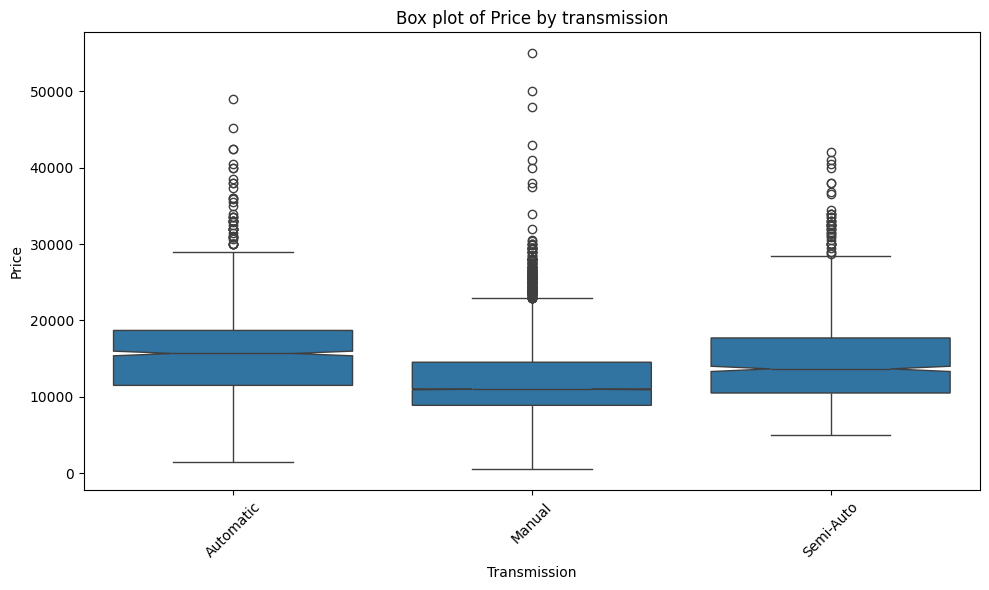

In [19]:
plt.figure(figsize=(10, 6)) 
sns.boxplot(x='transmission', y='price', data=df, notch=True) 
plt.xlabel('Transmission') 
plt.ylabel('Price') 
plt.title(f'Box plot of Price by transmission') 
plt.xticks(rotation=45) 
plt.tight_layout() 
plt.show()

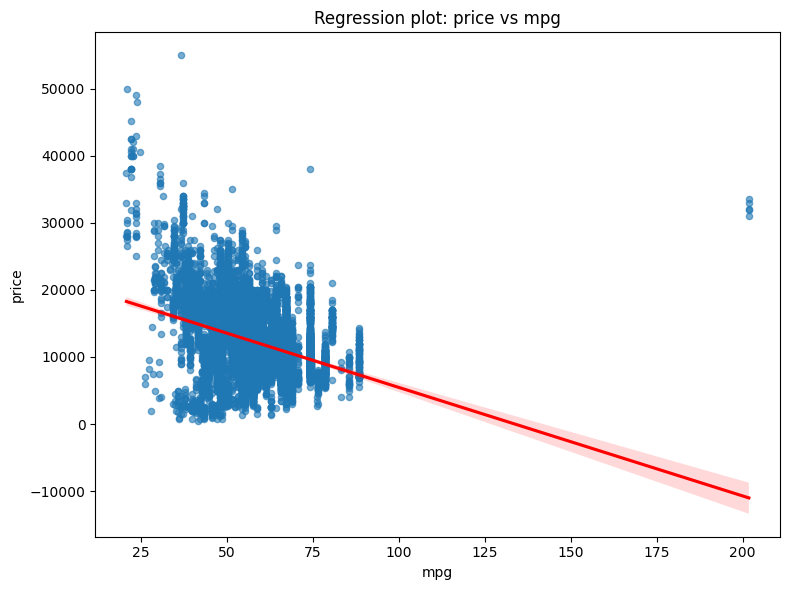

In [21]:
if not (pd.api.types.is_numeric_dtype(df['price']) and pd.api.types.is_numeric_dtype(df['mpg'])): 
    raise ValueError("Both source_attribute and target_attribute must be numeric for a regression plot.")
plt.figure(figsize=(8, 6)) 
sns.regplot(x='mpg', y='price', data=df, scatter_kws={'alpha': 0.6, 's': 20}, line_kws={'color': 'red'}) 
plt.xlabel('mpg') 
plt.ylabel('price') 
plt.title(f'Regression plot: price vs mpg') 
plt.tight_layout() 
plt.show()

In [36]:
def fit_linear_regression_and_metrics(source, target='price'):
    if df.shape[0] < 2:
        raise ValueError("Not enough samples after cleaning to fit a linear regression.")

    X = df[source].values  
    # shape (n_samples, 1)
    y = df[target].values

    model = LinearRegression()

    metrics = {}
    model.fit(X, y)
    y_pred = model.predict(X)
    metrics['r2'] = r2_score(y, y_pred)
    metrics['mse'] = mean_squared_error(y, y_pred)
    metrics['n'] = X.shape[0]
    return metrics

In [37]:
m_mpg = fit_linear_regression_and_metrics(['mpg'])
m_mpg

{'r2': 0.1198980224962416, 'mse': 19741690.809446193, 'n': 17812}

In [38]:
m_mult = fit_linear_regression_and_metrics(['year', 'mileage', 'tax', 'mpg', 'engineSize'])
m_mult

{'r2': 0.7265379654547005, 'mse': 6134065.224381731, 'n': 17812}

In [41]:
X = df[['year', 'mileage', 'tax', 'mpg', 'engineSize']].values
y = df['price'].values
# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])

metrics = {}
pipeline.fit(X, y)
y_pred = pipeline.predict(X)
metrics['r2'] = r2_score(y, y_pred)
metrics['mse'] = mean_squared_error(y, y_pred)
metrics['n'] = X.shape[0]
metrics

{'r2': 0.7666619695239302, 'mse': 5234038.065462741, 'n': 17812}

In [46]:
alpha = 0.1
random_state = 42
test_size = 0.2
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

# Ridge regression with alpha=0.1
model = Ridge(alpha=alpha)
model.fit(X_train, y_train)

# Predictions on the test set
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'r2 = {r2} mse={mse}')

r2 = 0.6917134446113066 mse=6912725.801055086


In [49]:
alpha = 0.1
random_state = 42
degree = 2
test_size = 0.2
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

# Ridge regression with alpha=0.1
model = Ridge(alpha=alpha)
model.fit(X_train_poly, y_train)

# Predictions on the test set
y_pred = model.predict(X_test_poly)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'r2 = {r2} mse={mse}')

/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.1777e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


r2 = 0.673274888823681 mse=7326174.5165419085


In [55]:
random_state = 42
degree = 2
test_size = 0.2
alphas = [0.1, 1.0, 10.0, 100.0]

X = df[['year', 'mileage', 'tax', 'mpg', 'engineSize']]
y = df['price']
# Identify categorical and numeric columns
cat_cols = [c for c in X.columns if X[c].dtype == 'object' or X[c].dtype.name == 'category']
num_cols = [c for c in X.columns if c not in cat_cols]
# Preprocessor: one-hot encode categoricals, pass through numerics
transformers = []
if num_cols:
    transformers.append(('num', 'passthrough', num_cols))
if cat_cols:
    transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols))
preprocessor = ColumnTransformer(transformers=transformers)

# Pipeline: preprocessor -> polynomial features degree 2 -> ridge
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
    ('ridge', Ridge())
])

param_grid = {'ridge__alpha': alphas}

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

# Grid search with cross-validation on training data
grid = GridSearchCV(estimator=pipe, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

grid.fit(X_train, y_train)

# Evaluate on the test set using the best model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

metric ={
    'best_model': best_model,
    'grid': grid,
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'y_pred': y_pred,
    'mse': mse,
    'r2': r2
}

metric

/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.70402e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.76139e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.75044e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.74159e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.64731e-24): res

{'best_model': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num', 'passthrough',
                                                   ['year', 'mileage', 'tax',
                                                    'mpg', 'engineSize'])])),
                 ('poly', PolynomialFeatures(include_bias=False)),
                 ('ridge', Ridge(alpha=0.1))]),
 'grid': GridSearchCV(cv=5,
              estimator=Pipeline(steps=[('preprocessor',
                                         ColumnTransformer(transformers=[('num',
                                                                          'passthrough',
                                                                          ['year',
                                                                           'mileage',
                                                                           'tax',
                                                                           'mpg',
                    

In [35]:
feature_cols = ['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category']
poly_cols = feature_cols #['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category']
target_col = 'Price'
cv_folds = 4
degrees = [2, 3]
alphas = [0.0001,0.001,0.01, 0.1, 1, 10]
# Validate columns
all_cols = set(feature_cols)
if not all(c in df.columns for c in feature_cols):
    raise ValueError("Some feature_cols are not present in the dataframe.")
if not all(c in df.columns for c in poly_cols):
    raise ValueError("Some poly_cols are not present in the dataframe.")
if target_col not in df.columns:
    raise ValueError("target_col not found in dataframe.")

if not set(poly_cols).issubset(set(feature_cols)):
    raise ValueError("poly_cols must be a subset of feature_cols.")

# Prepare data: keep only relevant columns, convert to numeric, drop NaNs
subset = df[feature_cols + [target_col]].copy()
for col in feature_cols:
    subset[col] = pd.to_numeric(subset[col], errors='coerce')
subset[target_col] = pd.to_numeric(subset[target_col], errors='coerce')
subset = subset.dropna()

if subset.shape[0] < 2:
    raise ValueError("Not enough valid data after cleaning NaNs.")

X = subset[feature_cols]  # shape (n_samples, n_features)
y = subset[target_col]

# Train/test split
#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, test_size=test_size, random_state=random_state
#)
X_train = X
y_train = y
X_test = X
y_test = y

# Build pipeline:
# - ColumnTransformer applies PolynomialFeatures to poly_cols
# - remainder='passthrough' keeps the other features as-is
preprocessor = ColumnTransformer(
    transformers=[
        ('poly', PolynomialFeatures(degree=2, include_bias=False), poly_cols)
    ],
    remainder='passthrough'
)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('ridge', Ridge())
])

# Grid search over degree of polynomial and Ridge alpha
param_grid = {
    'preprocessor__poly__degree': degrees,
    'ridge__alpha': alphas
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv_folds,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_estimator = grid.best_estimator_
y_pred_test = best_estimator.predict(X_test)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Verbose results
print("Grid Search Results:")
for i, params in enumerate(grid.cv_results_['params']):
    neg_mse_mean = grid.cv_results_['mean_test_score'][i]
    mse_mean = -neg_mse_mean
    print(f"  Params {i+1}: degree={params['preprocessor__poly__degree']}, "
          f"alpha={params['ridge__alpha']}, "
          f"Mean MSE={mse_mean:.6f}")

best_params = grid.best_params_
best_mse = -grid.best_score_
print("\nBest model:")
print(f"  degree={best_params['preprocessor__poly__degree']}, alpha={best_params['ridge__alpha']}")
print(f"  Cross-validated MSE={best_mse:.6f}")
print(f"  Test MSE={mse_test:.6f}, Test R^2={r2_test:.6f}")

#return best_estimator, X_train, X_test, y_train, y_test, y_pred_test, mse_test, r2_test

/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.15572e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=7.34116e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.80013e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.87571e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.69324e-19): res

Grid Search Results:
  Params 1: degree=2, alpha=0.0001, Mean MSE=202778.029070
  Params 2: degree=2, alpha=0.001, Mean MSE=201197.751173
  Params 3: degree=2, alpha=0.01, Mean MSE=191914.139320
  Params 4: degree=2, alpha=0.1, Mean MSE=183205.519756
  Params 5: degree=2, alpha=1, Mean MSE=178314.436307
  Params 6: degree=2, alpha=10, Mean MSE=170180.427468
  Params 7: degree=3, alpha=0.0001, Mean MSE=419800854.794372
  Params 8: degree=3, alpha=0.001, Mean MSE=200250160.101149
  Params 9: degree=3, alpha=0.01, Mean MSE=8318169.052957
  Params 10: degree=3, alpha=0.1, Mean MSE=2610146.779504
  Params 11: degree=3, alpha=1, Mean MSE=1166708.087703
  Params 12: degree=3, alpha=10, Mean MSE=449172.908466

Best model:
  degree=2, alpha=10
  Cross-validated MSE=170180.427468
  Test MSE=127241.858833, Test R^2=0.612996


## Authors


[Abhishek Gagneja](https://www.linkedin.com/in/abhishek-gagneja-23051987/)


## Change Log


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-12-10|0.1|Abhishek Gagneja|Initial Draft created|


Copyright © 2023 IBM Corporation. All rights reserved.
